# Pathway associated gene expression heatmap

This notebook will use heatmaps to visualize the gene expression for selected genes that correspond to selected pathways. These pathways have been selected for their roles in tumor proliferation and chemotherapy resistance.

1. Tumor Proliferation
    1. G2/M Cell Cycle Checkpoint
    2. E2F Regulation
2. Chemotherapy Resistance
    1. DNA Damage Response (DDR)
    2. Unfolded Protein Response (UPR)

For these heatmaps, the combined epithelial dataset does **not** filter out the following:

* Stromal cells
   * This cell type is located in connective tissues. [9]
   * "Source of cancer-associated fibroblasts" [9, 10]
* Genes with low variance across cells
   * The two types of cells being analyzed have different descriptive statistics which contributes to the likelihood that filtering out highly variable genes for each of these groups will be more difficult to compare.
   * The interest in this notebook is biolical signifcance and/or relevance. Keeping these genes ensures that key insights aren't missed just because they don't drive variance across all the cells.

## Average gene expressions

Using `scanpy.tl.score_genes`, calculate the *average* expression of the genes of interest.
Heatmaps will be generated from the average expression of selected genes from each of the pathways. Below is a list of the selected genes and the reference article used for choosing the genes for the pathway.

1. Tumor Proliferation
    1. G2/M Cell Cycle Checkpoint
        1. CDC25C; CDK1; PLK1; AURKA; WEE1. Kai Liu, et al. [4]
    1. E2F Regulation
        1. CDK1; CCNA2; E2F1; E2F2.  Zeyu Xing, et. al. [5]
2. Chemotherapy Resistance
    2. DNA Damage Response (DDR)
        2. BRCA1/BRCA2; RAD51; ATM; CHEK2; XRCC1. Emily Cybulla, et al. [6]
    2. Unfolded Protein Response (UPR)
        2. ATF6; XBP1; CHOP; GRP78 (BiP).; PERK [7]

This is supported by creating a read-only snapshot of the expression was created before any filtering and joining.

## 0. Initializations

In [1]:
# -- imports --
import anndata as ad
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

from signals_in_the_noise.preprocessing.gse161529 import GSE161529
from signals_in_the_noise.config import get_resources_path
from signals_in_the_noise.utils.visualization import get_figure_axes

In [2]:
# -- datasets --
gse = GSE161529()

In [3]:
all_real, all_noise = gse.get_combined_epithelial_dataset(
    real_filename="combined_epi_normal_pathway_real.h5ad",
    noise_filename="combined_epi_normal_pathway_noise.h5ad",
    remove_stromal=False,
)

## 1. "Real" cells

In [4]:
sc.tl.score_genes(
    all_real,
    gene_list=gse.tumor_proliferation_genes,
    score_name='tp_score',
    use_raw=True,
)
sc.tl.score_genes(
    all_real,
    gene_list=gse.chemo_resistance_genes,
    score_name='cr_score',
    use_raw=True,
)

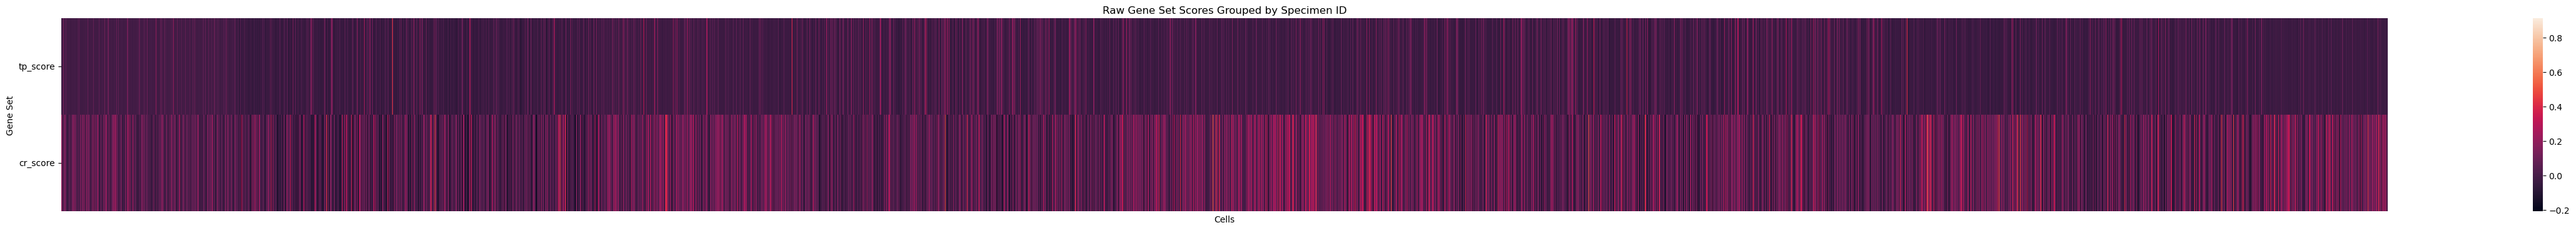

In [5]:
from signals_in_the_noise.utils.visualization import plot_score_heatmap

plot_score_heatmap(all_real, score_columns=['tp_score', 'cr_score'])
plt.show()

## 2. "Noise" cells

In [6]:
sc.tl.score_genes(
    all_noise,
    gene_list=gse.tumor_proliferation_genes,
    score_name='tp_score',
    use_raw=True,
)
sc.tl.score_genes(
    all_noise,
    gene_list=gse.chemo_resistance_genes,
    score_name='cr_score',
    use_raw=True,
)

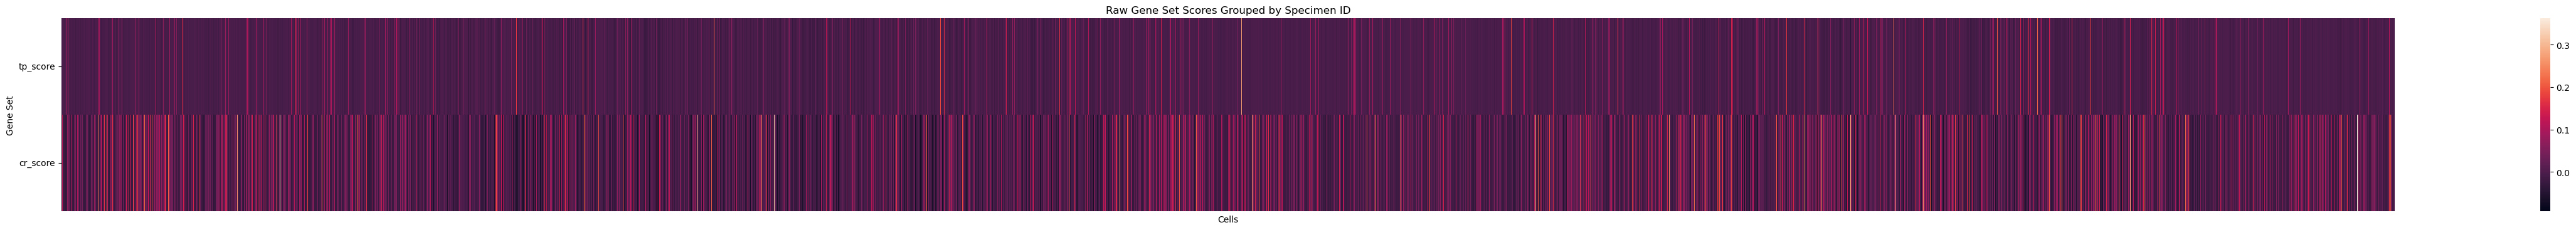

In [7]:
plot_score_heatmap(all_noise, score_columns=['tp_score', 'cr_score'])
plt.show()